# Synthetic SBM — Module-Compatible Verification Notebook

This notebook reproduces the original synthetic SBM experiment while only replacing the parts that are considered safe to modularize with `community_detection_utils.py`.

The goal is to check whether using the shared module preserves the original ARI/NMI results.

In [1]:
# Imports

%load_ext autoreload
%autoreload 2

import time

import warnings

import numpy as np

import pandas as pd

import networkx as nx

import community as community_louvain

from sklearn.metrics import (
    adjusted_rand_score,
    normalized_mutual_info_score,
)

from GraphRicciCurvature.OllivierRicci import OllivierRicci

import community_detection_utils as cdu

from pathlib import Path

import matplotlib.pyplot as plt

In [2]:
# ============================================================
# CELL 1 — WARNING CONFIGURATION
# ============================================================







warnings.filterwarnings("ignore")

In [3]:

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "environment.yml").is_file():
    if REPO_ROOT.parent == REPO_ROOT:
        raise FileNotFoundError("Could not locate the repository root.")
    REPO_ROOT = REPO_ROOT.parent

RESULTS_DIR = REPO_ROOT / "results" / "synthetic_module_verification"
TABLES_DIR = RESULTS_DIR / "tables"
SENSITIVITY_DIR = RESULTS_DIR / "sensitivity"
FIGURES_DIR = REPO_ROOT / "figures" / "synthetic_module_verification"

for output_dir in (TABLES_DIR, SENSITIVITY_DIR, FIGURES_DIR):
    output_dir.mkdir(parents=True, exist_ok=True)

OUTPUT_DIR = FIGURES_DIR
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [4]:
# ============================================================
# CELL 2 — FIXED EXPERIMENTAL PARAMETERS
# ============================================================

FIXED_PARAMS = dict(
    n_communities=4,
    community_size=90,
    p_in=0.15,
    p_out=0.022,
    bridge_blocks=10,
    bridge_block_size=8,
)

PCT_LRC_ONLY = 50
PCT_LRC_COMBO = 15
PCT_ORC = 20

ALPHA_ORC = 0.5

RICCI_FLOW_STEPS = 3
RICCI_FLOW_ETA = 1.0

N_SEEDS = 10
RANDOM_SEED = 42

In [5]:
# ============================================================
# CELL 3 — SYNTHETIC GRAPH GENERATION
# ============================================================

def generate_graph(seed, **params):

    rng = np.random.default_rng(seed)

    sizes = (
        [params["community_size"]]
        * params["n_communities"]
    )

    probs = np.full(
        (
            params["n_communities"],
            params["n_communities"],
        ),
        params["p_out"],
    )

    np.fill_diagonal(
        probs,
        params["p_in"],
    )

    G = nx.stochastic_block_model(
        sizes,
        probs,
        seed=seed,
    )

    labels = {}
    community_nodes = []

    start = 0

    for c, size in enumerate(sizes):

        nodes = list(
            range(
                start,
                start + size,
            )
        )

        community_nodes.append(nodes)

        for node in nodes:
            labels[node] = c

        start += size

    # Triangle-rich inter-community bridge blocks
    for _ in range(params["bridge_blocks"]):

        c1, c2 = rng.choice(
            params["n_communities"],
            size=2,
            replace=False,
        )

        block1 = rng.choice(
            community_nodes[c1],
            params["bridge_block_size"],
            replace=False,
        )

        block2 = rng.choice(
            community_nodes[c2],
            params["bridge_block_size"],
            replace=False,
        )

        for u in block1:
            for v in block2:
                G.add_edge(int(u), int(v))

    # MODULE FUNCTION #1
    G = cdu.get_gcc(G)

    labels = {
        node: labels[node]
        for node in G.nodes()
    }

    # MODULE FUNCTION #2
    G = cdu.ensure_edge_weights(
        G,
        weight="weight",
        default_weight=1.0,
        copy_graph=False,
    )

    return G, labels

In [6]:
# ============================================================
# CELL 4 — LRC USING SHARED MODULE
# ============================================================

def lrc_prune(G, pct):

    H = G.copy()

    # Compute LRC using the shared implementation
    cdu.compute_LRC(
        H,
        attribute="LRC",
    )

    # Prune low-LRC edges using the shared implementation
    H_pruned, cutoff, removed = cdu.prune_by_percentile(
        H,
        attr="LRC",
        pct=pct,
    )

    return H_pruned, cutoff, removed

In [7]:
# ============================================================
# CELL 5 — ORC + RICCI FLOW USING SHARED MODULE
# ============================================================

def orc_flow_prune(
    G,
    pct=20,
    alpha=0.5,
    flow_steps=3,
    eta=1.0,   # kept only for compatibility with existing calls
):

    # Run Ricci flow using shared module
    H_flow = cdu.run_orc_flow_gcc(
        G,
        alpha=alpha,
        iterations=flow_steps,
        method="Sinkhorn",
        weight="weight",
    )

    # Prune low final ORC edges using shared module
    H_pruned, cutoff, removed = cdu.prune_by_percentile(
        H_flow,
        attr="ricciCurvature",
        pct=pct,
    )

    H_pruned = cdu.get_gcc(
        H_pruned
    )

    return H_pruned, cutoff, removed

In [8]:
# ============================================================
# CELL 6 — EVALUATION
# ============================================================

def evaluate_graph(G, labels):

    # MODULE FUNCTION #4
    partition = cdu.run_louvain(
        G,
        weight="weight",
        seed=RANDOM_SEED,
    )

    nodes = sorted(G.nodes())

    y_true = [
        labels[node]
        for node in nodes
    ]

    y_pred = [
        partition[node]
        for node in nodes
    ]

    ari = adjusted_rand_score(
        y_true,
        y_pred,
    )

    nmi = normalized_mutual_info_score(
        y_true,
        y_pred,
    )

    modularity = community_louvain.modularity(
        partition,
        G,
        weight="weight",
    )

    return (
        ari,
        nmi,
        modularity,
    )

In [9]:
# ============================================================
# CELL 7 — GRAPH STATISTICS
# ============================================================

def graph_stats(G):

    # MODULE FUNCTION #5
    stats = cdu.basic_graph_stats(
        G,
        include_path_metrics=False,
    )

    return (
        stats["nodes"],
        stats["edges"],
        stats["density"],
        stats["avg_degree"],
    )

In [10]:
# ============================================================
# CELL 8 — THREE PIPELINES
# ============================================================

def run_lrc_only(
    G,
    labels,
    pct,
):

    t0 = time.time()

    t1 = time.time()

    H, _, removed = lrc_prune(
        G,
        pct,
    )

    lrc_time = time.time() - t1

    t2 = time.time()

    ari, nmi, mod = evaluate_graph(
        H,
        labels,
    )

    louvain_time = time.time() - t2

    return {
        "pipeline": "LRC-only",
        "ARI": ari,
        "NMI": nmi,
        "Modularity": mod,
        "LRC_time": lrc_time,
        "ORC_flow_time": 0.0,
        "Louvain_time": louvain_time,
        "Total_time": time.time() - t0,
        "removed_lrc": removed,
        "removed_orc": 0,
        "V": H.number_of_nodes(),
        "E": H.number_of_edges(),
    }


def run_orc_only(
    G,
    labels,
    pct,
    alpha,
    flow_steps,
    eta,
):

    t0 = time.time()

    t1 = time.time()

    H, _, removed = orc_flow_prune(
        G,
        pct,
        alpha,
        flow_steps,
        eta,
    )

    orc_flow_time = time.time() - t1

    t2 = time.time()

    ari, nmi, mod = evaluate_graph(
        H,
        labels,
    )

    louvain_time = time.time() - t2

    return {
        "pipeline": "ORC-only",
        "ARI": ari,
        "NMI": nmi,
        "Modularity": mod,
        "LRC_time": 0.0,
        "ORC_flow_time": orc_flow_time,
        "Louvain_time": louvain_time,
        "Total_time": time.time() - t0,
        "removed_lrc": 0,
        "removed_orc": removed,
        "V": H.number_of_nodes(),
        "E": H.number_of_edges(),
    }


def run_combo(
    G,
    labels,
    pct_lrc,
    pct_orc,
    alpha,
    flow_steps,
    eta,
):

    t0 = time.time()

    t1 = time.time()

    H1, _, removed_l = lrc_prune(
        G,
        pct_lrc,
    )

    lrc_time = time.time() - t1

    t2 = time.time()

    H2, _, removed_o = orc_flow_prune(
        H1,
        pct_orc,
        alpha,
        flow_steps,
        eta,
    )

    orc_flow_time = time.time() - t2
    sparsification_time = time.time() - t0

    t3 = time.time()

    ari, nmi, mod = evaluate_graph(
        H2,
        labels,
    )

    louvain_time = time.time() - t3

    return {
        "pipeline": "Combo (LRC->ORC)",
        "ARI": ari,
        "NMI": nmi,
        "Modularity": mod,
        "LRC_time": lrc_time,
        "ORC_flow_time": orc_flow_time,
        "Louvain_time": louvain_time,
        "Sparsification_time": sparsification_time,
        "Total_time": sparsification_time,
        "removed_lrc": removed_l,
        "removed_orc": removed_o,
        "V": H2.number_of_nodes(),
        "E": H2.number_of_edges(),
    }

In [11]:
# ============================================================
# CELL 9 — MAIN EXPERIMENT
# ============================================================

all_rows = []

print(
    f"Running {N_SEEDS} independent graph realizations...\n"
)

print(
    f"Ricci flow steps T = {RICCI_FLOW_STEPS}, "
    f"eta = {RICCI_FLOW_ETA}\n"
)

for seed in range(
    1,
    N_SEEDS + 1,
):

    G, labels = generate_graph(
        seed,
        **FIXED_PARAMS,
    )

    r_lrc = run_lrc_only(
        G,
        labels,
        pct=PCT_LRC_ONLY,
    )

    r_orc = run_orc_only(
        G,
        labels,
        pct=PCT_ORC,
        alpha=ALPHA_ORC,
        flow_steps=RICCI_FLOW_STEPS,
        eta=RICCI_FLOW_ETA,
    )

    r_combo = run_combo(
        G,
        labels,
        pct_lrc=PCT_LRC_COMBO,
        pct_orc=PCT_ORC,
        alpha=ALPHA_ORC,
        flow_steps=RICCI_FLOW_STEPS,
        eta=RICCI_FLOW_ETA,
    )

    for result in [
        r_lrc,
        r_orc,
        r_combo,
    ]:
        result["seed"] = seed

    all_rows.extend(
        [
            r_lrc,
            r_orc,
            r_combo,
        ]
    )

    print(
        f"Seed {seed:2d} | "
        f"LRC ARI={r_lrc['ARI']:.3f} | "
        f"ORC ARI={r_orc['ARI']:.3f} | "
        f"Combo ARI={r_combo['ARI']:.3f} | "
        f"Combo time={r_combo['Total_time']:.2f}s | "
        f"ORC time={r_orc['Total_time']:.2f}s"
    )

df = pd.DataFrame(
    all_rows
)

Running 10 independent graph realizations...

Ricci flow steps T = 3, eta = 1.0

Seed  1 | LRC ARI=0.630 | ORC ARI=0.885 | Combo ARI=0.797 | Combo time=12.16s | ORC time=20.38s
Seed  2 | LRC ARI=0.631 | ORC ARI=0.840 | Combo ARI=0.871 | Combo time=12.11s | ORC time=19.50s
Seed  3 | LRC ARI=0.472 | ORC ARI=0.833 | Combo ARI=0.728 | Combo time=11.82s | ORC time=19.37s
Seed  4 | LRC ARI=0.715 | ORC ARI=0.803 | Combo ARI=0.660 | Combo time=12.40s | ORC time=20.43s
Seed  5 | LRC ARI=0.599 | ORC ARI=0.853 | Combo ARI=0.777 | Combo time=12.93s | ORC time=21.15s
Seed  6 | LRC ARI=0.716 | ORC ARI=0.864 | Combo ARI=0.823 | Combo time=12.65s | ORC time=21.28s
Seed  7 | LRC ARI=0.661 | ORC ARI=0.821 | Combo ARI=0.793 | Combo time=11.95s | ORC time=19.28s
Seed  8 | LRC ARI=0.559 | ORC ARI=0.906 | Combo ARI=0.850 | Combo time=12.09s | ORC time=20.03s
Seed  9 | LRC ARI=0.669 | ORC ARI=0.866 | Combo ARI=0.808 | Combo time=12.64s | ORC time=20.61s
Seed 10 | LRC ARI=0.600 | ORC ARI=0.872 | Combo ARI=0.7

In [12]:
# ============================================================
# CELL 10 — SUMMARY
# ============================================================

summary_cols = [
    "ARI",
    "NMI",
    "Modularity",
    "Total_time",
]

summary = (
    df
    .groupby("pipeline")[summary_cols]
    .agg(["mean", "std"])
    .round(4)
)

print("\n" + "=" * 70)
print("RESULTS (mean +/- std across seeds)")
print("=" * 70)

display(summary)

rows_fmt = []

for pipe in [
    "LRC-only",
    "ORC-only",
    "Combo (LRC->ORC)",
]:

    sub = df[
        df["pipeline"] == pipe
    ]

    rows_fmt.append(
        {
            "Pipeline": pipe,

            "ARI mean+/-std":
                cdu.mean_pm_std(
                    sub["ARI"],
                    digits=3,
                ),

            "NMI mean+/-std":
                cdu.mean_pm_std(
                    sub["NMI"],
                    digits=3,
                ),

            "Time mean+/-std":
                cdu.mean_pm_std(
                    sub["Total_time"],
                    digits=2,
                ),
        }
    )

df_fmt = pd.DataFrame(
    rows_fmt
).set_index("Pipeline")

display(df_fmt)


RESULTS (mean +/- std across seeds)


ARI             NMI         Modularity          \
                    mean     std    mean     std       mean     std   
pipeline                                                              
Combo (LRC->ORC)  0.7865  0.0609  0.7745  0.0374     0.5533  0.0135   
LRC-only          0.6250  0.0737  0.6407  0.0537     0.5061  0.0192   
ORC-only          0.8543  0.0307  0.8325  0.0261     0.4905  0.0079   

                 Total_time          
                       mean     std  
pipeline                             
Combo (LRC->ORC)    12.3272  0.3548  
LRC-only             0.0878  0.0273  
ORC-only            20.2535  0.7046

,ARI mean+/-std,NMI mean+/-std,Time mean+/-std
Pipeline,,,
LRC-only,0.625 ± 0.074,0.641 ± 0.054,0.09 ± 0.03
ORC-only,0.854 ± 0.031,0.833 ± 0.026,20.25 ± 0.70
Combo (LRC->ORC),0.786 ± 0.061,0.775 ± 0.037,12.33 ± 0.35


In [13]:
# ============================================================
# CELL 11 — VERIFY AGAINST ORIGINAL RESULTS
# ============================================================

EXPECTED = {
    "LRC-only": {
        "ARI": 0.6320,
        "NMI": 0.6371,
    },

    "ORC-only": {
        "ARI": 0.8544,
        "NMI": 0.8357,
    },

    "Combo (LRC->ORC)": {
        "ARI": 0.8049,
        "NMI": 0.7846,
    },
}

print("=" * 75)
print("COMPARISON WITH ORIGINAL SYNTHETIC RESULTS")
print("=" * 75)

for pipeline, expected in EXPECTED.items():

    subset = df[
        df["pipeline"] == pipeline
    ]

    ari_new = subset["ARI"].mean()
    nmi_new = subset["NMI"].mean()

    print(f"\n{pipeline}")

    print(
        f"  Original ARI : "
        f"{expected['ARI']:.4f}"
    )

    print(
        f"  New ARI      : "
        f"{ari_new:.4f}"
    )

    print(
        f"  ARI difference: "
        f"{ari_new - expected['ARI']:+.6f}"
    )

    print(
        f"  Original NMI : "
        f"{expected['NMI']:.4f}"
    )

    print(
        f"  New NMI      : "
        f"{nmi_new:.4f}"
    )

    print(
        f"  NMI difference: "
        f"{nmi_new - expected['NMI']:+.6f}"
    )

COMPARISON WITH ORIGINAL SYNTHETIC RESULTS

LRC-only
  Original ARI : 0.6320
  New ARI      : 0.6250
  ARI difference: -0.006959
  Original NMI : 0.6371
  New NMI      : 0.6407
  NMI difference: +0.003642

ORC-only
  Original ARI : 0.8544
  New ARI      : 0.8543
  ARI difference: -0.000057
  Original NMI : 0.8357
  New NMI      : 0.8325
  NMI difference: -0.003193

Combo (LRC->ORC)
  Original ARI : 0.8049
  New ARI      : 0.7865
  ARI difference: -0.018432
  Original NMI : 0.7846
  New NMI      : 0.7745
  NMI difference: -0.010059


Default configuration:
  LRC pruning = 15%
  ORC pruning = 20%
  alpha       = 0.5
  flow steps  = 3
  eta         = 1.0
  seeds       = [1, 2, 3, 4, 5]

LRC PRUNING SENSITIVITY
LRC= 0% | ORC=20% | alpha=0.5
LRC= 5% | ORC=20% | alpha=0.5
LRC=10% | ORC=20% | alpha=0.5
LRC=15% | ORC=20% | alpha=0.5
LRC=20% | ORC=20% | alpha=0.5
LRC=25% | ORC=20% | alpha=0.5
LRC=30% | ORC=20% | alpha=0.5

ORC PRUNING SENSITIVITY
LRC=15% | ORC= 5% | alpha=0.5
LRC=15% | ORC=10% | alpha=0.5
LRC=15% | ORC=15% | alpha=0.5
LRC=15% | ORC=20% | alpha=0.5
LRC=15% | ORC=25% | alpha=0.5
LRC=15% | ORC=30% | alpha=0.5

ALPHA SENSITIVITY
LRC=15% | ORC=20% | alpha=0.00
LRC=15% | ORC=20% | alpha=0.25
LRC=15% | ORC=20% | alpha=0.50
LRC=15% | ORC=20% | alpha=0.75

LRC pruning sensitivity:


,lrc_pct,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,V_mean,V_std,E_mean,E_std,Removed_LRC_mean,Removed_ORC_mean
0,0,0.842791,0.029810,0.822304,0.020236,20.143843,0.580595,360.0,0.000000,3244.8,38.015786,0.0,811.6
1,5,0.815423,0.063893,0.801429,0.050981,17.370548,0.582606,360.0,0.000000,3080.4,36.943200,205.2,770.8
2,10,0.813910,0.060374,0.798531,0.048462,14.616884,0.453449,360.0,0.000000,2919.6,35.004285,406.6,730.2
3,15,0.766493,0.078606,0.760588,0.045612,12.419947,0.372091,360.0,0.000000,2756.2,33.551453,610.8,689.4
4,20,0.801244,0.040695,0.773121,0.036554,10.779669,0.288856,359.6,0.894427,2595.0,30.911163,811.8,649.4
5,25,0.771928,0.054413,0.751549,0.035323,9.422682,0.296990,360.0,0.000000,2431.8,29.836220,1016.4,608.2
6,30,0.717665,0.052258,0.706673,0.036909,8.218498,0.223596,359.6,0.894427,2267.4,27.700181,1221.6,567.4



ORC pruning sensitivity:


,orc_pct,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,V_mean,V_std,E_mean,E_std,Removed_LRC_mean,Removed_ORC_mean
0,5,0.792628,0.067339,0.768502,0.051239,12.436734,0.388491,360.0,0.000000,3272.8,39.971240,610.8,172.8
1,10,0.818135,0.049109,0.793059,0.038310,12.423104,0.326572,360.0,0.000000,3100.6,37.819307,610.8,345.0
2,15,0.802239,0.039699,0.780240,0.025502,12.095516,0.361450,360.0,0.000000,2928.2,35.884537,610.8,517.4
3,20,0.766493,0.078606,0.760588,0.045612,12.123179,0.455241,360.0,0.000000,2756.2,33.551453,610.8,689.4
4,25,0.767764,0.014287,0.746487,0.021770,12.135538,0.394925,360.0,0.000000,2583.8,31.618033,610.8,861.8
5,30,0.751702,0.036820,0.734168,0.030468,12.139084,0.365626,359.4,0.894427,2411.4,29.652993,610.8,1034.0



Alpha sensitivity:


,alpha,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,V_mean,V_std,E_mean,E_std,Removed_LRC_mean,Removed_ORC_mean
0,0.00,0.609176,0.046103,0.621547,0.032511,0.578021,0.076011,358.8,0.836660,2756.2,33.551453,610.8,689.4
1,0.25,0.824077,0.030064,0.796596,0.022342,9.855493,0.286748,360.0,0.000000,2756.2,33.551453,610.8,689.4
2,0.50,0.766493,0.078606,0.760588,0.045612,12.193704,0.413503,360.0,0.000000,2756.2,33.551453,610.8,689.4
3,0.75,0.762058,0.046540,0.750451,0.024324,13.658496,0.462466,359.6,0.894427,2756.0,33.734256,610.8,689.4


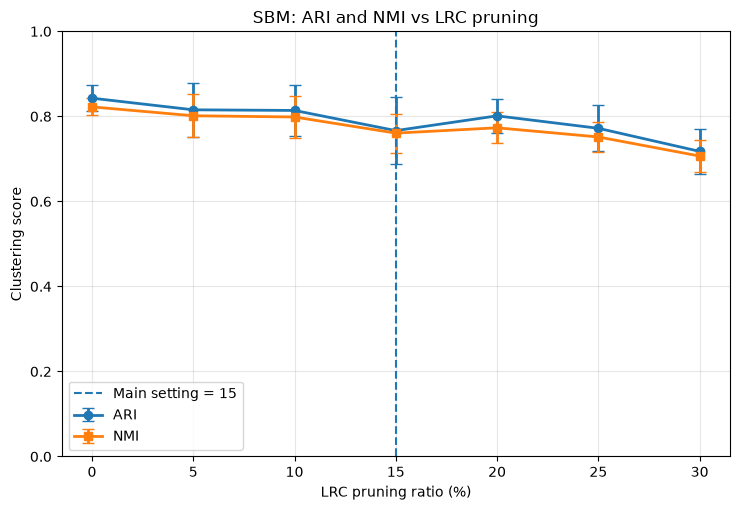

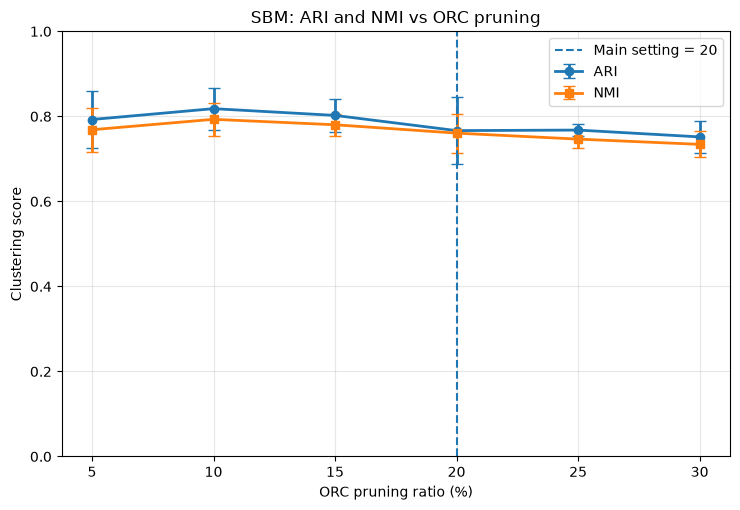

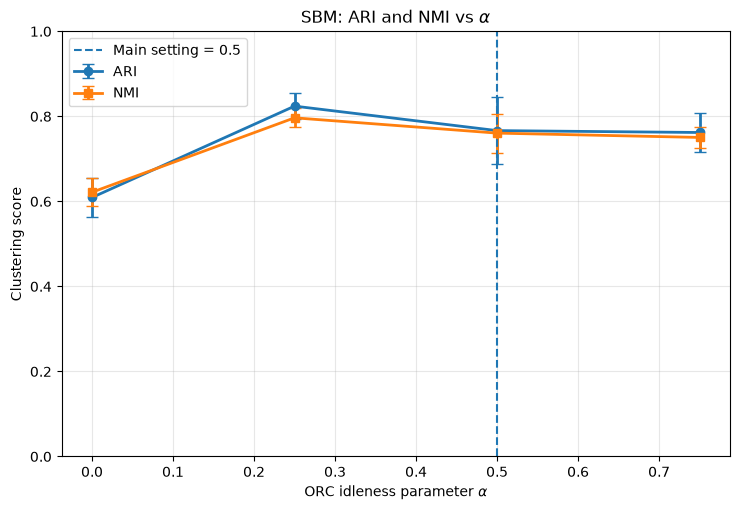


Sensitivity analysis completed.


In [14]:
# ============================================================
# CELL 12 — PARAMETER SENSITIVITY ANALYSIS
# ============================================================



# ------------------------------------------------------------
# 1. Sensitivity settings
# ------------------------------------------------------------

# Same independent graph realizations used for each parameter value
SENSITIVITY_SEEDS = [1, 2, 3, 4, 5]

# Parameter values to investigate
LRC_PRUNING_VALUES = [0, 5, 10, 15, 20, 25, 30]

ORC_PRUNING_VALUES = [5, 10, 15, 20, 25, 30]

ALPHA_VALUES = [0.00, 0.25, 0.50, 0.75]


# Main/default configuration
DEFAULT_LRC_PRUNING = PCT_LRC_COMBO
DEFAULT_ORC_PRUNING = PCT_ORC
DEFAULT_ALPHA = ALPHA_ORC


print("Default configuration:")
print(f"  LRC pruning = {DEFAULT_LRC_PRUNING}%")
print(f"  ORC pruning = {DEFAULT_ORC_PRUNING}%")
print(f"  alpha       = {DEFAULT_ALPHA}")
print(f"  flow steps  = {RICCI_FLOW_STEPS}")
print(f"  eta         = {RICCI_FLOW_ETA}")
print(f"  seeds       = {SENSITIVITY_SEEDS}")


# ============================================================
# 2. Evaluate one Combo configuration
# ============================================================

def evaluate_combo_configuration(
    lrc_pct,
    orc_pct,
    alpha,
    seeds,
):
    """
    Run one LRC->ORC parameter configuration across
    several independent synthetic SBM realizations.
    """

    rows = []

    for seed in seeds:

        # Same graph-generation procedure as the main experiment
        G, labels = generate_graph(
            seed,
            **FIXED_PARAMS,
        )

        result = run_combo(
            G=G,
            labels=labels,
            pct_lrc=lrc_pct,
            pct_orc=orc_pct,
            alpha=alpha,
            flow_steps=RICCI_FLOW_STEPS,
            eta=RICCI_FLOW_ETA,
        )

        rows.append(
            {
                "seed": seed,
                "lrc_pct": lrc_pct,
                "orc_pct": orc_pct,
                "alpha": alpha,

                "ARI": result["ARI"],
                "NMI": result["NMI"],
                "Runtime": result["Total_time"],

                "V": result["V"],
                "E": result["E"],

                "removed_lrc":
                    result["removed_lrc"],

                "removed_orc":
                    result["removed_orc"],
            }
        )

    return rows


# ============================================================
# 3. LRC pruning sensitivity
# ============================================================

lrc_sweep_rows = []

print("\n" + "=" * 70)
print("LRC PRUNING SENSITIVITY")
print("=" * 70)

for lrc_pct in LRC_PRUNING_VALUES:

    print(
        f"LRC={lrc_pct:>2}% | "
        f"ORC={DEFAULT_ORC_PRUNING}% | "
        f"alpha={DEFAULT_ALPHA}"
    )

    rows = evaluate_combo_configuration(
        lrc_pct=lrc_pct,
        orc_pct=DEFAULT_ORC_PRUNING,
        alpha=DEFAULT_ALPHA,
        seeds=SENSITIVITY_SEEDS,
    )

    lrc_sweep_rows.extend(
        rows
    )


df_lrc_sensitivity = pd.DataFrame(
    lrc_sweep_rows
)


# ============================================================
# 4. ORC pruning sensitivity
# ============================================================

orc_sweep_rows = []

print("\n" + "=" * 70)
print("ORC PRUNING SENSITIVITY")
print("=" * 70)

for orc_pct in ORC_PRUNING_VALUES:

    print(
        f"LRC={DEFAULT_LRC_PRUNING}% | "
        f"ORC={orc_pct:>2}% | "
        f"alpha={DEFAULT_ALPHA}"
    )

    rows = evaluate_combo_configuration(
        lrc_pct=DEFAULT_LRC_PRUNING,
        orc_pct=orc_pct,
        alpha=DEFAULT_ALPHA,
        seeds=SENSITIVITY_SEEDS,
    )

    orc_sweep_rows.extend(
        rows
    )


df_orc_sensitivity = pd.DataFrame(
    orc_sweep_rows
)


# ============================================================
# 5. Alpha sensitivity
# ============================================================

alpha_sweep_rows = []

print("\n" + "=" * 70)
print("ALPHA SENSITIVITY")
print("=" * 70)

for alpha in ALPHA_VALUES:

    print(
        f"LRC={DEFAULT_LRC_PRUNING}% | "
        f"ORC={DEFAULT_ORC_PRUNING}% | "
        f"alpha={alpha:.2f}"
    )

    rows = evaluate_combo_configuration(
        lrc_pct=DEFAULT_LRC_PRUNING,
        orc_pct=DEFAULT_ORC_PRUNING,
        alpha=alpha,
        seeds=SENSITIVITY_SEEDS,
    )

    alpha_sweep_rows.extend(
        rows
    )


df_alpha_sensitivity = pd.DataFrame(
    alpha_sweep_rows
)


# ============================================================
# 6. Summaries: mean +/- standard deviation
# ============================================================

def summarize_sensitivity(
    dataframe,
    parameter_column,
):

    return (
        dataframe
        .groupby(
            parameter_column,
            as_index=False,
        )
        .agg(
            ARI_mean=("ARI", "mean"),
            ARI_std=("ARI", "std"),

            NMI_mean=("NMI", "mean"),
            NMI_std=("NMI", "std"),

            Runtime_mean=("Runtime", "mean"),
            Runtime_std=("Runtime", "std"),

            V_mean=("V", "mean"),
            V_std=("V", "std"),

            E_mean=("E", "mean"),
            E_std=("E", "std"),

            Removed_LRC_mean=(
                "removed_lrc",
                "mean",
            ),

            Removed_ORC_mean=(
                "removed_orc",
                "mean",
            ),
        )
        .sort_values(
            parameter_column
        )
        .reset_index(
            drop=True
        )
    )


lrc_sensitivity_summary = (
    summarize_sensitivity(
        df_lrc_sensitivity,
        "lrc_pct",
    )
)

orc_sensitivity_summary = (
    summarize_sensitivity(
        df_orc_sensitivity,
        "orc_pct",
    )
)

alpha_sensitivity_summary = (
    summarize_sensitivity(
        df_alpha_sensitivity,
        "alpha",
    )
)


print(
    "\nLRC pruning sensitivity:"
)
display(
    lrc_sensitivity_summary
)

print(
    "\nORC pruning sensitivity:"
)
display(
    orc_sensitivity_summary
)

print(
    "\nAlpha sensitivity:"
)
display(
    alpha_sensitivity_summary
)


# ============================================================
# 7. Plot ARI + NMI together
# ============================================================

def plot_ari_nmi_sensitivity(
    summary,
    x_col,
    x_label,
    title,
    default_value,
):

    fig, ax = plt.subplots(
        figsize=(7.5, 5.2)
    )

    ax.errorbar(
        summary[x_col],
        summary["ARI_mean"],
        yerr=summary["ARI_std"],
        marker="o",
        linewidth=2,
        capsize=4,
        label="ARI",
    )

    ax.errorbar(
        summary[x_col],
        summary["NMI_mean"],
        yerr=summary["NMI_std"],
        marker="s",
        linewidth=2,
        capsize=4,
        label="NMI",
    )

    ax.axvline(
        default_value,
        linestyle="--",
        linewidth=1.5,
        label=f"Main setting = {default_value}",
    )

    ax.set_xlabel(
        x_label
    )

    ax.set_ylabel(
        "Clustering score"
    )

    ax.set_title(
        title
    )

    ax.set_ylim(
        0,
        1,
    )

    ax.grid(
        alpha=0.3
    )

    ax.legend()

    fig.tight_layout()

    plt.show()


# LRC plot
plot_ari_nmi_sensitivity(
    summary=lrc_sensitivity_summary,
    x_col="lrc_pct",
    x_label="LRC pruning ratio (%)",
    title="SBM: ARI and NMI vs LRC pruning",
    default_value=DEFAULT_LRC_PRUNING,
)


# ORC plot
plot_ari_nmi_sensitivity(
    summary=orc_sensitivity_summary,
    x_col="orc_pct",
    x_label="ORC pruning ratio (%)",
    title="SBM: ARI and NMI vs ORC pruning",
    default_value=DEFAULT_ORC_PRUNING,
)


# Alpha plot
plot_ari_nmi_sensitivity(
    summary=alpha_sensitivity_summary,
    x_col="alpha",
    x_label=r"ORC idleness parameter $\alpha$",
    title=r"SBM: ARI and NMI vs $\alpha$",
    default_value=DEFAULT_ALPHA,
)


print(
    "\nSensitivity analysis completed."
)

In [15]:
# ============================================================
# RANDOM PARAMETER SENSITIVITY
# LRC pruning: 0--100%
# ORC pruning: 0--100%
# alpha:       0--1
# ============================================================



# ------------------------------------------------------------
# SETTINGS
# ------------------------------------------------------------

N_RANDOM_CONFIGS = 50

# Graph realizations used for every random configuration
RANDOM_SENSITIVITY_SEEDS = [1, 2, 3, 4, 5]

# Reproducible random parameter sampling
PARAMETER_RANDOM_SEED = 2026

rng = np.random.default_rng(
    PARAMETER_RANDOM_SEED
)


# ============================================================
# 1. RANDOM PARAMETER CONFIGURATIONS
# ============================================================

random_configs = []

for config_id in range(N_RANDOM_CONFIGS):

    # Integer pruning percentages from 0 to 100 inclusive
    lrc_pct = int(
        rng.integers(
            0,
            101
        )
    )

    orc_pct = int(
        rng.integers(
            0,
            101
        )
    )

    # Continuous alpha between 0 and 1
    alpha = float(
        rng.uniform(
            0.0,
            1.0
        )
    )

    random_configs.append(
        {
            "config_id": config_id,
            "lrc_pct": lrc_pct,
            "orc_pct": orc_pct,
            "alpha": alpha,
        }
    )


df_random_configs = pd.DataFrame(
    random_configs
)

print("Random parameter configurations:")
display(
    df_random_configs.head(20)
)


# ============================================================
# 2. RUN RANDOM CONFIGURATIONS
# ============================================================

random_results = []


print(
    "\n"
    + "=" * 80
)

print(
    "RANDOM LRC / ORC / ALPHA SENSITIVITY"
)

print(
    "=" * 80
)


for _, config in df_random_configs.iterrows():

    config_id = int(
        config["config_id"]
    )

    lrc_pct = float(
        config["lrc_pct"]
    )

    orc_pct = float(
        config["orc_pct"]
    )

    alpha = float(
        config["alpha"]
    )


    print(
        f"\nConfig {config_id:02d} | "
        f"LRC={lrc_pct:.0f}% | "
        f"ORC={orc_pct:.0f}% | "
        f"alpha={alpha:.3f}"
    )


    for seed in RANDOM_SENSITIVITY_SEEDS:

        try:

            # -----------------------------------------------
            # Generate exactly the same synthetic graph type
            # used in the main experiment
            # -----------------------------------------------

            G, labels = generate_graph(
                seed,
                **FIXED_PARAMS,
            )


            # -----------------------------------------------
            # Run Combo pipeline
            # -----------------------------------------------

            result = run_combo(
                G=G,
                labels=labels,
                pct_lrc=lrc_pct,
                pct_orc=orc_pct,
                alpha=alpha,
                flow_steps=RICCI_FLOW_STEPS,
                eta=RICCI_FLOW_ETA,
            )


            random_results.append(
                {
                    "config_id": config_id,
                    "seed": seed,

                    "lrc_pct": lrc_pct,
                    "orc_pct": orc_pct,
                    "alpha": alpha,

                    "ARI": result["ARI"],
                    "NMI": result["NMI"],
                    "Runtime": result["Total_time"],

                    "V": result["V"],
                    "E": result["E"],

                    "removed_lrc":
                        result["removed_lrc"],

                    "removed_orc":
                        result["removed_orc"],

                    "status": "ok",
                    "error": "",
                }
            )


        except Exception as error:

            print(
                f"   Seed {seed}: FAILED -> "
                f"{type(error).__name__}"
            )

            random_results.append(
                {
                    "config_id": config_id,
                    "seed": seed,

                    "lrc_pct": lrc_pct,
                    "orc_pct": orc_pct,
                    "alpha": alpha,

                    "ARI": np.nan,
                    "NMI": np.nan,
                    "Runtime": np.nan,

                    "V": np.nan,
                    "E": np.nan,

                    "removed_lrc": np.nan,
                    "removed_orc": np.nan,

                    "status": "failed",
                    "error": repr(error),
                }
            )


df_random_sensitivity = pd.DataFrame(
    random_results
)


# ============================================================
# 3. KEEP SUCCESSFUL RUNS
# ============================================================

df_random_valid = (
    df_random_sensitivity[
        df_random_sensitivity["status"] == "ok"
    ]
    .copy()
)


print(
    "\nSuccessful runs:",
    len(df_random_valid),
)

print(
    "Failed runs:",
    (
        df_random_sensitivity["status"]
        == "failed"
    ).sum(),
)


# ============================================================
# 4. MEAN +/- STD FOR EACH RANDOM CONFIGURATION
# ============================================================

random_summary = (
    df_random_valid
    .groupby(
        [
            "config_id",
            "lrc_pct",
            "orc_pct",
            "alpha",
        ],
        as_index=False,
    )
    .agg(
        ARI_mean=("ARI", "mean"),
        ARI_std=("ARI", "std"),

        NMI_mean=("NMI", "mean"),
        NMI_std=("NMI", "std"),

        Runtime_mean=("Runtime", "mean"),
        Runtime_std=("Runtime", "std"),

        V_mean=("V", "mean"),
        E_mean=("E", "mean"),

        Removed_LRC_mean=(
            "removed_lrc",
            "mean",
        ),

        Removed_ORC_mean=(
            "removed_orc",
            "mean",
        ),

        n_runs=(
            "seed",
            "nunique",
        ),
    )
)


# ============================================================
# 5. SHOW BEST CONFIGURATIONS
# ============================================================

print(
    "\nTop configurations by ARI:"
)

display(
    random_summary
    .sort_values(
        "ARI_mean",
        ascending=False,
    )
    .head(15)
)


print(
    "\nTop configurations by NMI:"
)

display(
    random_summary
    .sort_values(
        "NMI_mean",
        ascending=False,
    )
    .head(15)
)


# ============================================================
# 6. SAVE RESULTS
# ============================================================

df_random_sensitivity.to_csv(
    SENSITIVITY_DIR / "sbm_random_parameter_sensitivity_raw.csv",
    index=False,
)

random_summary.to_csv(
    SENSITIVITY_DIR / "sbm_random_parameter_sensitivity_summary.csv",
    index=False,
)


print(
    "\nSaved:"
)

print(
    "  sbm_random_parameter_sensitivity_raw.csv"
)

print(
    "  sbm_random_parameter_sensitivity_summary.csv"
)

Random parameter configurations:


,config_id,lrc_pct,orc_pct,alpha
0,0,86,18,0.639913
1,1,36,47,0.370501
2,2,64,35,0.790518
3,3,71,91,0.177353
4,4,86,65,0.298303
5,5,16,97,0.919850
6,6,28,64,0.752732
7,7,11,52,0.825895
8,8,66,45,0.338812
9,9,15,28,0.226333



RANDOM LRC / ORC / ALPHA SENSITIVITY

Config 00 | LRC=86% | ORC=18% | alpha=0.640

Config 01 | LRC=36% | ORC=47% | alpha=0.371

Config 02 | LRC=64% | ORC=35% | alpha=0.791

Config 03 | LRC=71% | ORC=91% | alpha=0.177

Config 04 | LRC=86% | ORC=65% | alpha=0.298

Config 05 | LRC=16% | ORC=97% | alpha=0.920

Config 06 | LRC=28% | ORC=64% | alpha=0.753

Config 07 | LRC=11% | ORC=52% | alpha=0.826

Config 08 | LRC=66% | ORC=45% | alpha=0.339

Config 09 | LRC=15% | ORC=28% | alpha=0.226

Config 10 | LRC=86% | ORC=53% | alpha=0.431

Config 11 | LRC=27% | ORC=66% | alpha=0.013

Config 12 | LRC=47% | ORC=45% | alpha=0.365

Config 13 | LRC=16% | ORC=19% | alpha=0.595

Config 14 | LRC=32% | ORC=43% | alpha=0.300

Config 15 | LRC=97% | ORC=21% | alpha=0.875

Config 16 | LRC=96% | ORC=80% | alpha=0.607

Config 17 | LRC=20% | ORC=34% | alpha=0.947

Config 18 | LRC=80% | ORC=56% | alpha=0.433

Config 19 | LRC=42% | ORC=90% | alpha=0.319

Config 20 | LRC=41% | ORC=70% | alpha=0.314

Config 21 | LRC=

,config_id,lrc_pct,orc_pct,alpha,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,V_mean,E_mean,Removed_LRC_mean,Removed_ORC_mean,n_runs
16,16,96.0,80.0,0.606710,1.000000,0.000000,1.000000,0.000000,0.709960,0.023803,2.40,1.4,3893.8,34.4,5
49,49,99.0,23.0,0.599316,1.000000,0.000000,1.000000,0.000000,0.700504,0.030574,3.25,2.5,4024.0,1.5,4
13,13,16.0,19.0,0.594866,0.800203,0.033876,0.778868,0.024219,12.580964,0.357433,360.00,2758.0,651.2,647.2,5
37,37,95.0,89.0,0.620935,0.800000,0.447214,0.800000,0.447214,0.769861,0.041255,2.80,1.8,3854.0,80.2,5
40,40,98.0,28.0,0.671826,0.800000,0.447214,0.800000,0.447214,0.686302,0.006018,4.20,3.4,3974.8,2.8,5
21,21,7.0,26.0,0.700841,0.797842,0.028894,0.774276,0.032786,17.870888,0.599290,360.00,2790.4,285.4,980.6,5
9,9,15.0,28.0,0.226333,0.780659,0.033158,0.760851,0.031692,9.637327,0.241557,360.00,2480.6,610.8,965.0,5
38,38,30.0,16.0,0.947062,0.713010,0.044911,0.702955,0.032657,8.005971,0.193580,359.80,2381.0,1221.6,453.8,5
33,33,35.0,5.0,0.358231,0.682433,0.134173,0.674105,0.095771,6.725562,0.189259,360.00,2502.0,1422.2,132.2,5
41,41,6.0,49.0,0.092889,0.661851,0.180572,0.666937,0.160152,10.540341,0.317873,319.20,1761.0,245.0,1867.6,5



Top configurations by NMI:


,config_id,lrc_pct,orc_pct,alpha,ARI_mean,ARI_std,NMI_mean,NMI_std,Runtime_mean,Runtime_std,V_mean,E_mean,Removed_LRC_mean,Removed_ORC_mean,n_runs
16,16,96.0,80.0,0.606710,1.000000,0.000000,1.000000,0.000000,0.709960,0.023803,2.40,1.4,3893.8,34.4,5
49,49,99.0,23.0,0.599316,1.000000,0.000000,1.000000,0.000000,0.700504,0.030574,3.25,2.5,4024.0,1.5,4
37,37,95.0,89.0,0.620935,0.800000,0.447214,0.800000,0.447214,0.769861,0.041255,2.80,1.8,3854.0,80.2,5
40,40,98.0,28.0,0.671826,0.800000,0.447214,0.800000,0.447214,0.686302,0.006018,4.20,3.4,3974.8,2.8,5
13,13,16.0,19.0,0.594866,0.800203,0.033876,0.778868,0.024219,12.580964,0.357433,360.00,2758.0,651.2,647.2,5
21,21,7.0,26.0,0.700841,0.797842,0.028894,0.774276,0.032786,17.870888,0.599290,360.00,2790.4,285.4,980.6,5
9,9,15.0,28.0,0.226333,0.780659,0.033158,0.760851,0.031692,9.637327,0.241557,360.00,2480.6,610.8,965.0,5
38,38,30.0,16.0,0.947062,0.713010,0.044911,0.702955,0.032657,8.005971,0.193580,359.80,2381.0,1221.6,453.8,5
17,17,20.0,34.0,0.946820,0.660843,0.062377,0.674979,0.036342,10.383309,0.260883,355.80,2141.2,811.8,1103.2,5
33,33,35.0,5.0,0.358231,0.682433,0.134173,0.674105,0.095771,6.725562,0.189259,360.00,2502.0,1422.2,132.2,5



Saved:
  sbm_random_parameter_sensitivity_raw.csv
  sbm_random_parameter_sensitivity_summary.csv


In [16]:
# ============================================================
# HEATMAP TIMING WARM-UP
# ============================================================

WARMUP_TOTAL_NODES = 2500
WARMUP_RATIO = 0.15
WARMUP_TARGET_DEGREE = 25
WARMUP_ALPHA = 0.5
WARMUP_SEEDS = [0, 1]

warmup_community_size = (
    WARMUP_TOTAL_NODES
    // FIXED_PARAMS["n_communities"]
)

warmup_p_in = WARMUP_TARGET_DEGREE / (
    (warmup_community_size - 1)
    + (
        WARMUP_TOTAL_NODES
        - warmup_community_size
    )
    * WARMUP_RATIO
)

warmup_graph_params = {
    **FIXED_PARAMS,
    "community_size": warmup_community_size,
    "p_in": warmup_p_in,
    "p_out": WARMUP_RATIO * warmup_p_in,
    "bridge_blocks": max(
        FIXED_PARAMS["bridge_blocks"],
        round(
            FIXED_PARAMS["bridge_blocks"]
            * WARMUP_TOTAL_NODES
            / 360
        ),
    ),
}

for warmup_seed in WARMUP_SEEDS:
    warmup_graph, warmup_labels = generate_graph(
        seed=warmup_seed,
        **warmup_graph_params,
    )

    run_combo(
        G=warmup_graph,
        labels=warmup_labels,
        pct_lrc=20,
        pct_orc=20,
        alpha=WARMUP_ALPHA,
        flow_steps=RICCI_FLOW_STEPS,
        eta=RICCI_FLOW_ETA,
    )

print(
    "Timing warm-up complete; measured heat-map runs follow."
)

Timing warm-up complete; measured heat-map runs follow.


JOINT LRC-ORC PRUNING SENSITIVITY ACROSS SBM RATIOS
vertices: 2500
community size: 625
target degree: 25
ratios: [0.05, 0.1, 0.15, 0.2, 0.3]
LRC values: [0, 10, 20, 30, 40, 50]
ORC values: [0, 10, 20, 30, 40, 50]
seeds: [1, 2, 3, 4, 5]

Running SBM with n=2500, p_in=0.034831, p_out=0.001742, ratio=0.05
  LRC=0% | ORC=0% | ratio=0.05
  LRC=0% | ORC=10% | ratio=0.05
  LRC=0% | ORC=20% | ratio=0.05
  LRC=0% | ORC=30% | ratio=0.05
  LRC=0% | ORC=40% | ratio=0.05
  LRC=0% | ORC=50% | ratio=0.05
  LRC=10% | ORC=0% | ratio=0.05
  LRC=10% | ORC=10% | ratio=0.05
  LRC=10% | ORC=20% | ratio=0.05
  LRC=10% | ORC=30% | ratio=0.05
  LRC=10% | ORC=40% | ratio=0.05
  LRC=10% | ORC=50% | ratio=0.05
  LRC=20% | ORC=0% | ratio=0.05
  LRC=20% | ORC=10% | ratio=0.05
  LRC=20% | ORC=20% | ratio=0.05
  LRC=20% | ORC=30% | ratio=0.05
  LRC=20% | ORC=40% | ratio=0.05
  LRC=20% | ORC=50% | ratio=0.05
  LRC=30% | ORC=0% | ratio=0.05
  LRC=30% | ORC=10% | ratio=0.05
  LRC=30% | ORC=20% | ratio=0.05
  LRC=30% | O

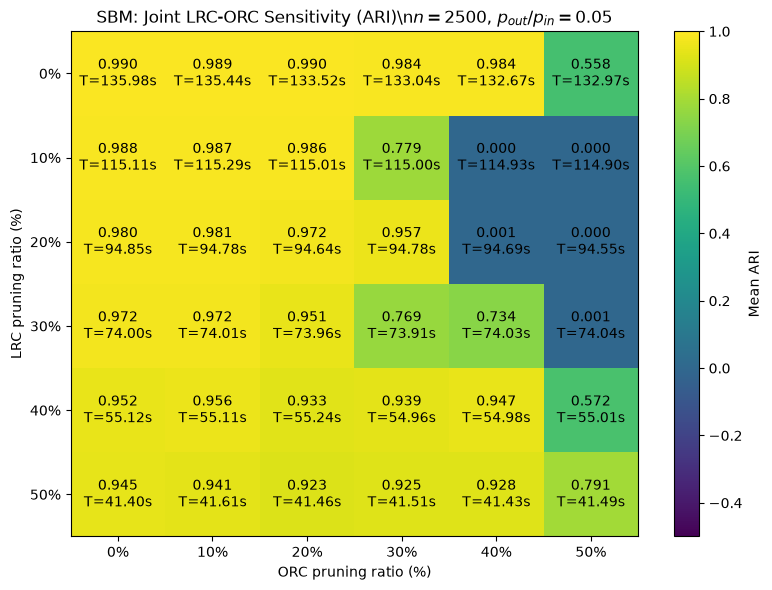

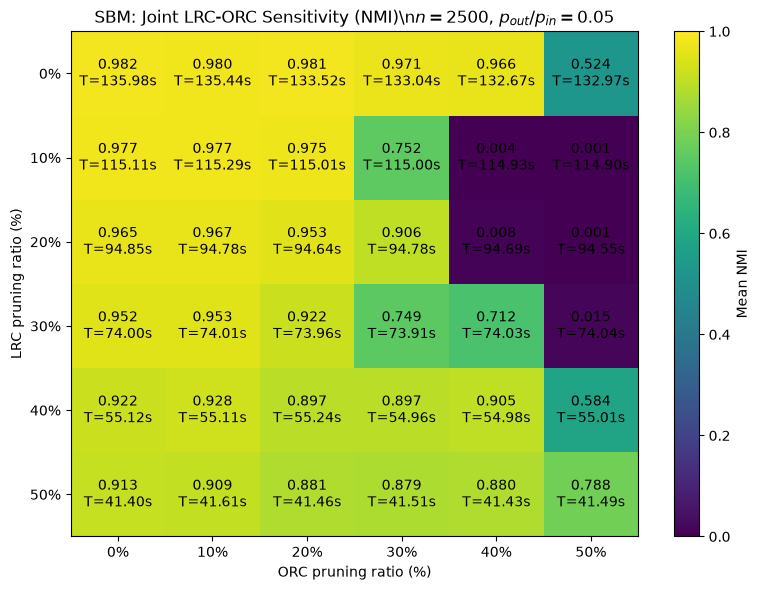

  Saved ARI and NMI heatmaps plus CSV results.

Running SBM with n=2500, p_in=0.030807, p_out=0.003081, ratio=0.10
  LRC=0% | ORC=0% | ratio=0.10
  LRC=0% | ORC=10% | ratio=0.10
  LRC=0% | ORC=20% | ratio=0.10
  LRC=0% | ORC=30% | ratio=0.10
  LRC=0% | ORC=40% | ratio=0.10
  LRC=0% | ORC=50% | ratio=0.10
  LRC=10% | ORC=0% | ratio=0.10
  LRC=10% | ORC=10% | ratio=0.10
  LRC=10% | ORC=20% | ratio=0.10
  LRC=10% | ORC=30% | ratio=0.10
  LRC=10% | ORC=40% | ratio=0.10
  LRC=10% | ORC=50% | ratio=0.10
  LRC=20% | ORC=0% | ratio=0.10
  LRC=20% | ORC=10% | ratio=0.10
  LRC=20% | ORC=20% | ratio=0.10
  LRC=20% | ORC=30% | ratio=0.10
  LRC=20% | ORC=40% | ratio=0.10
  LRC=20% | ORC=50% | ratio=0.10
  LRC=30% | ORC=0% | ratio=0.10
  LRC=30% | ORC=10% | ratio=0.10
  LRC=30% | ORC=20% | ratio=0.10
  LRC=30% | ORC=30% | ratio=0.10
  LRC=30% | ORC=40% | ratio=0.10
  LRC=30% | ORC=50% | ratio=0.10
  LRC=40% | ORC=0% | ratio=0.10
  LRC=40% | ORC=10% | ratio=0.10
  LRC=40% | ORC=20% | ratio=0.10
  LRC

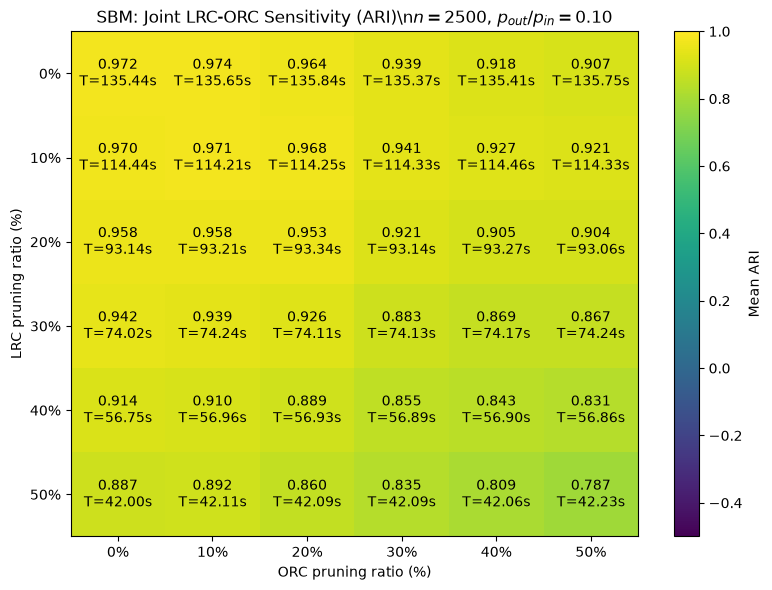

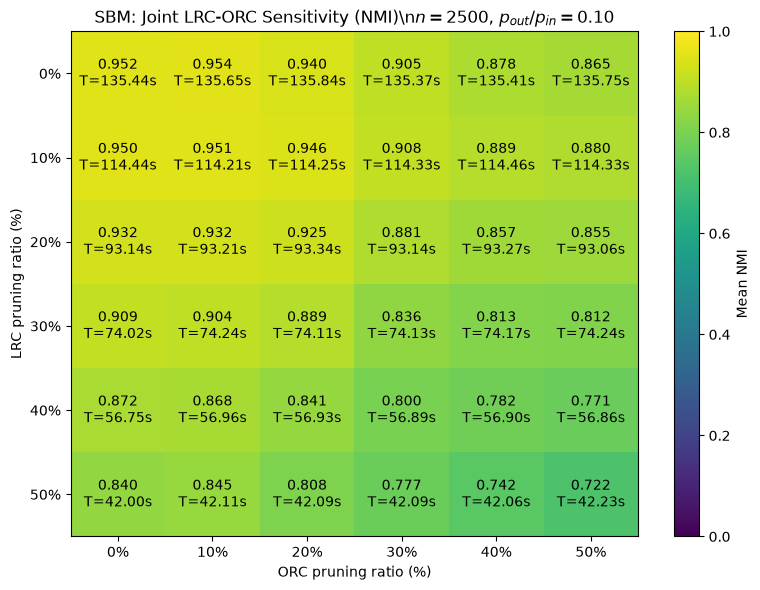

  Saved ARI and NMI heatmaps plus CSV results.

Running SBM with n=2500, p_in=0.027617, p_out=0.004143, ratio=0.15
  LRC=0% | ORC=0% | ratio=0.15
  LRC=0% | ORC=10% | ratio=0.15
  LRC=0% | ORC=20% | ratio=0.15
  LRC=0% | ORC=30% | ratio=0.15
  LRC=0% | ORC=40% | ratio=0.15
  LRC=0% | ORC=50% | ratio=0.15
  LRC=10% | ORC=0% | ratio=0.15
  LRC=10% | ORC=10% | ratio=0.15
  LRC=10% | ORC=20% | ratio=0.15
  LRC=10% | ORC=30% | ratio=0.15
  LRC=10% | ORC=40% | ratio=0.15
  LRC=10% | ORC=50% | ratio=0.15
  LRC=20% | ORC=0% | ratio=0.15
  LRC=20% | ORC=10% | ratio=0.15
  LRC=20% | ORC=20% | ratio=0.15
  LRC=20% | ORC=30% | ratio=0.15
  LRC=20% | ORC=40% | ratio=0.15
  LRC=20% | ORC=50% | ratio=0.15
  LRC=30% | ORC=0% | ratio=0.15
  LRC=30% | ORC=10% | ratio=0.15
  LRC=30% | ORC=20% | ratio=0.15
  LRC=30% | ORC=30% | ratio=0.15
  LRC=30% | ORC=40% | ratio=0.15
  LRC=30% | ORC=50% | ratio=0.15
  LRC=40% | ORC=0% | ratio=0.15
  LRC=40% | ORC=10% | ratio=0.15
  LRC=40% | ORC=20% | ratio=0.15
  LRC

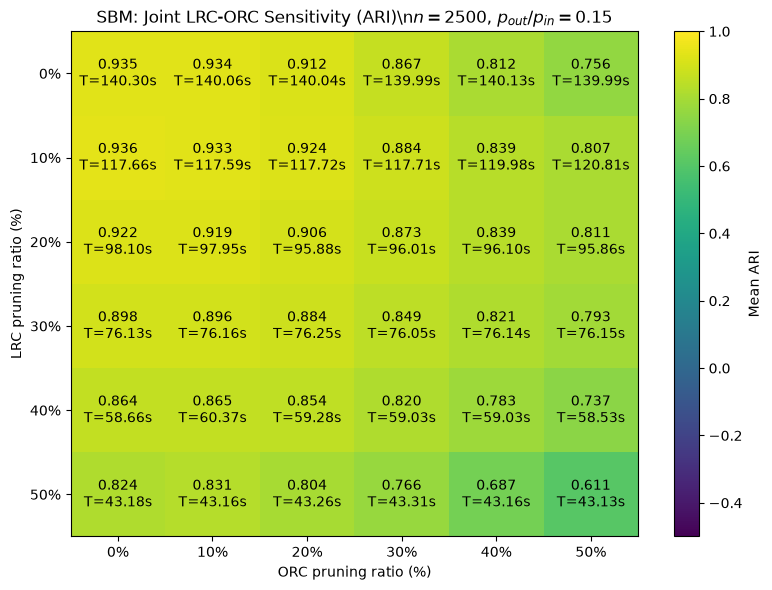

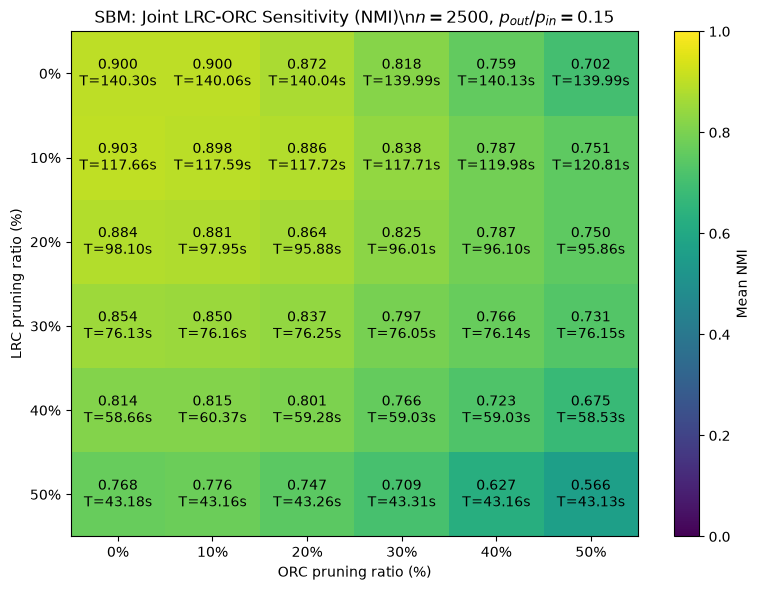

  Saved ARI and NMI heatmaps plus CSV results.

Running SBM with n=2500, p_in=0.025025, p_out=0.005005, ratio=0.20
  LRC=0% | ORC=0% | ratio=0.20
  LRC=0% | ORC=10% | ratio=0.20
  LRC=0% | ORC=20% | ratio=0.20
  LRC=0% | ORC=30% | ratio=0.20
  LRC=0% | ORC=40% | ratio=0.20
  LRC=0% | ORC=50% | ratio=0.20
  LRC=10% | ORC=0% | ratio=0.20
  LRC=10% | ORC=10% | ratio=0.20
  LRC=10% | ORC=20% | ratio=0.20
  LRC=10% | ORC=30% | ratio=0.20
  LRC=10% | ORC=40% | ratio=0.20
  LRC=10% | ORC=50% | ratio=0.20
  LRC=20% | ORC=0% | ratio=0.20
  LRC=20% | ORC=10% | ratio=0.20
  LRC=20% | ORC=20% | ratio=0.20
  LRC=20% | ORC=30% | ratio=0.20
  LRC=20% | ORC=40% | ratio=0.20
  LRC=20% | ORC=50% | ratio=0.20
  LRC=30% | ORC=0% | ratio=0.20
  LRC=30% | ORC=10% | ratio=0.20
  LRC=30% | ORC=20% | ratio=0.20
  LRC=30% | ORC=30% | ratio=0.20
  LRC=30% | ORC=40% | ratio=0.20
  LRC=30% | ORC=50% | ratio=0.20
  LRC=40% | ORC=0% | ratio=0.20
  LRC=40% | ORC=10% | ratio=0.20
  LRC=40% | ORC=20% | ratio=0.20
  LRC

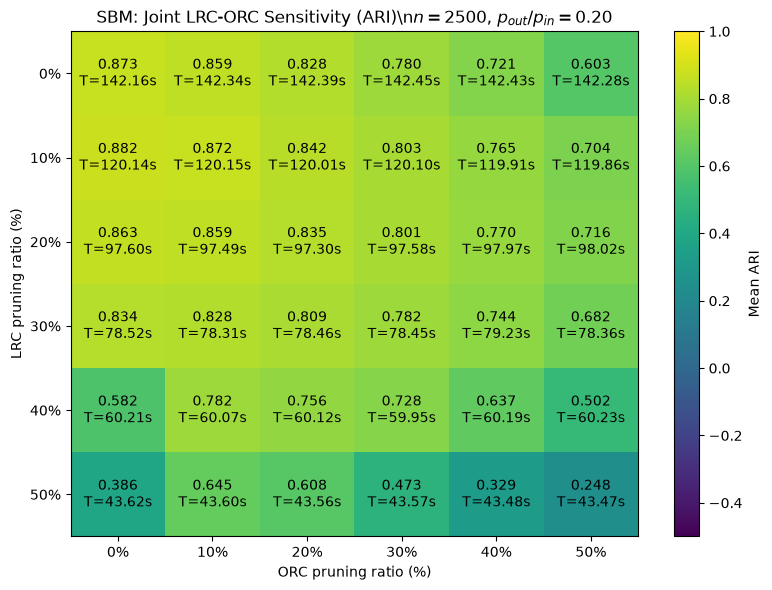

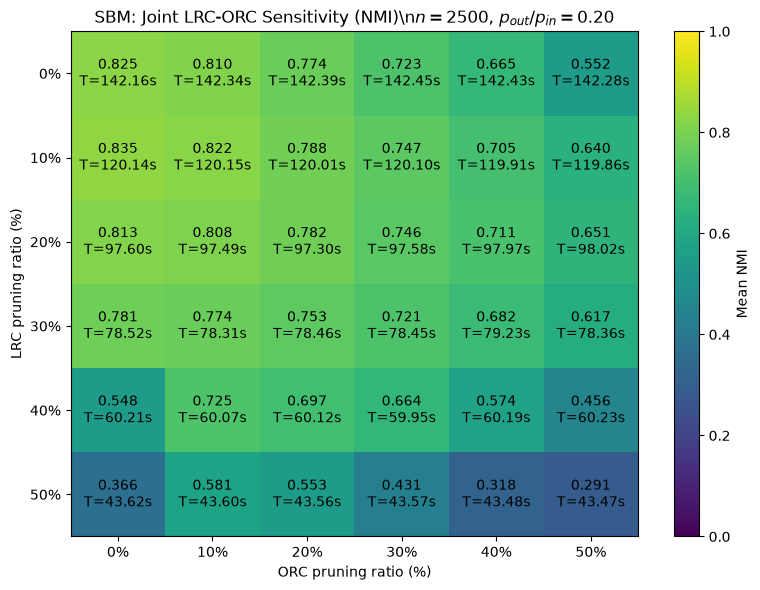

  Saved ARI and NMI heatmaps plus CSV results.

Running SBM with n=2500, p_in=0.021070, p_out=0.006321, ratio=0.30
  LRC=0% | ORC=0% | ratio=0.30
  LRC=0% | ORC=10% | ratio=0.30
  LRC=0% | ORC=20% | ratio=0.30
  LRC=0% | ORC=30% | ratio=0.30
  LRC=0% | ORC=40% | ratio=0.30
  LRC=0% | ORC=50% | ratio=0.30
  LRC=10% | ORC=0% | ratio=0.30
  LRC=10% | ORC=10% | ratio=0.30
  LRC=10% | ORC=20% | ratio=0.30
  LRC=10% | ORC=30% | ratio=0.30
  LRC=10% | ORC=40% | ratio=0.30
  LRC=10% | ORC=50% | ratio=0.30
  LRC=20% | ORC=0% | ratio=0.30
  LRC=20% | ORC=10% | ratio=0.30
  LRC=20% | ORC=20% | ratio=0.30
  LRC=20% | ORC=30% | ratio=0.30
  LRC=20% | ORC=40% | ratio=0.30
  LRC=20% | ORC=50% | ratio=0.30
  LRC=30% | ORC=0% | ratio=0.30
  LRC=30% | ORC=10% | ratio=0.30
  LRC=30% | ORC=20% | ratio=0.30
  LRC=30% | ORC=30% | ratio=0.30
  LRC=30% | ORC=40% | ratio=0.30
  LRC=30% | ORC=50% | ratio=0.30
  LRC=40% | ORC=0% | ratio=0.30
  LRC=40% | ORC=10% | ratio=0.30
  LRC=40% | ORC=20% | ratio=0.30
  LRC

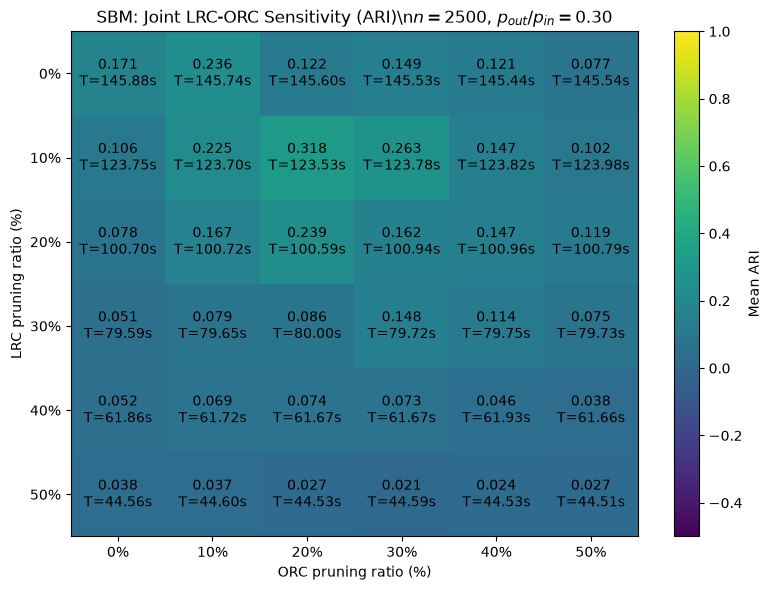

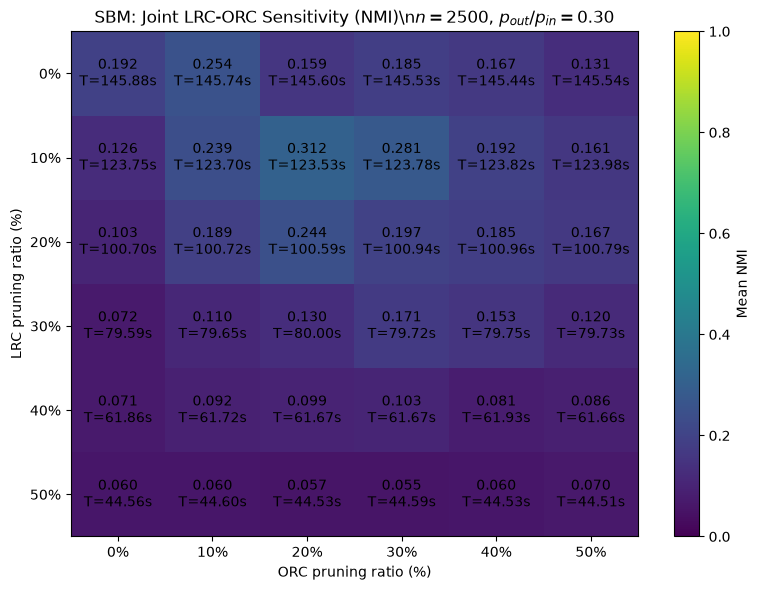

  Saved ARI and NMI heatmaps plus CSV results.


In [17]:
# ============================================================
# JOINT LRC-ORC PRUNING HEATMAPS ACROSS SBM RATIOS
# ============================================================



# ------------------------------------------------------------
# 1. Controlled SBM parameter settings
# ------------------------------------------------------------

N_VERTICES = 2500
N_COMMUNITIES = FIXED_PARAMS["n_communities"]
COMMUNITY_SIZE = N_VERTICES // N_COMMUNITIES
TARGET_DEGREE = 25
SBM_RATIOS = [0.05, 0.10, 0.15, 0.20, 0.30]

LRC_HEAT_VALUES = [0, 10, 20, 30, 40, 50]
ORC_HEAT_VALUES = [0, 10, 20, 30, 40, 50]

HEATMAP_ALPHA = 0.5
HEATMAP_SEEDS = [1, 2, 3, 4, 5]


def probabilities_for_sbm(
    total_nodes,
    ratio,
    target_degree=25,
    n_communities=4,
):
    """Set p_in and p_out while approximately preserving mean degree."""
    community_size = total_nodes / n_communities

    p_in = target_degree / (
        (community_size - 1)
        + (total_nodes - community_size) * ratio
    )

    return p_in, ratio * p_in


SBM_CONFIGS = []

for ratio in SBM_RATIOS:
    p_in, p_out = probabilities_for_sbm(
        total_nodes=N_VERTICES,
        ratio=ratio,
        target_degree=TARGET_DEGREE,
        n_communities=N_COMMUNITIES,
    )

    SBM_CONFIGS.append(
        {
            "n_vertices": N_VERTICES,
            "community_size": COMMUNITY_SIZE,
            "ratio": ratio,
            "p_in": p_in,
            "p_out": p_out,
        }
    )


print("JOINT LRC-ORC PRUNING SENSITIVITY ACROSS SBM RATIOS")
print("vertices:", N_VERTICES)
print("community size:", COMMUNITY_SIZE)
print("target degree:", TARGET_DEGREE)
print("ratios:", SBM_RATIOS)
print("LRC values:", LRC_HEAT_VALUES)
print("ORC values:", ORC_HEAT_VALUES)
print("seeds:", HEATMAP_SEEDS)


# ============================================================
# 2. Plotting helper
# ============================================================

def plot_metric_heatmap(
    matrix,
    metric_name,
    total_nodes,
    ratio,
    runtime_matrix=None,
):
    fig, ax = plt.subplots(figsize=(8, 6))

    if metric_name == "ARI":
        vmin, vmax = -0.5, 1.0
    else:
        vmin, vmax = 0.0, 1.0

    im = ax.imshow(
        matrix.values,
        vmin=vmin,
        vmax=vmax,
        aspect="auto",
    )

    ax.set_xticks(np.arange(len(ORC_HEAT_VALUES)))
    ax.set_xticklabels([f"{value}%" for value in ORC_HEAT_VALUES])
    ax.set_yticks(np.arange(len(LRC_HEAT_VALUES)))
    ax.set_yticklabels([f"{value}%" for value in LRC_HEAT_VALUES])

    ax.set_xlabel("ORC pruning ratio (%)")
    ax.set_ylabel("LRC pruning ratio (%)")
    ax.set_title(
        rf"SBM: Joint LRC-ORC Sensitivity ({metric_name})\n"
        rf"$n={total_nodes}$, "
        rf"$p_{{out}}/p_{{in}}={ratio:.2f}$"
    )

    for i, lrc_pct in enumerate(LRC_HEAT_VALUES):
        for j, orc_pct in enumerate(ORC_HEAT_VALUES):
            metric_value = matrix.loc[lrc_pct, orc_pct]

            if runtime_matrix is not None:
                runtime_value = runtime_matrix.loc[lrc_pct, orc_pct]
                cell_text = f"{metric_value:.3f}\nT={runtime_value:.2f}s"
            else:
                cell_text = f"{metric_value:.3f}"

            ax.text(
                j,
                i,
                cell_text,
                ha="center",
                va="center",
                fontsize=10,
            )

    cbar = fig.colorbar(im, ax=ax)
    cbar.set_label(f"Mean {metric_name}")
    fig.tight_layout()

    return fig


# ============================================================
# 3. Run one heatmap for each ratio
# ============================================================

for config in SBM_CONFIGS:
    total_nodes = config["n_vertices"]
    ratio = config["ratio"]
    p_in = config["p_in"]
    p_out = config["p_out"]

    print(
        f"\nRunning SBM with n={total_nodes}, "
        f"p_in={p_in:.6f}, p_out={p_out:.6f}, "
        f"ratio={ratio:.2f}"
    )

    graph_params = {
        **FIXED_PARAMS,
        "community_size": config["community_size"],
        "p_in": p_in,
        "p_out": p_out,
        "bridge_blocks": max(
            FIXED_PARAMS["bridge_blocks"],
            round(
                FIXED_PARAMS["bridge_blocks"]
                * total_nodes
                / 360
            ),
        ),
    }

    heatmap_rows = []

    for lrc_pct in LRC_HEAT_VALUES:
        for orc_pct in ORC_HEAT_VALUES:
            print(
                f"  LRC={lrc_pct}% | "
                f"ORC={orc_pct}% | "
                f"ratio={ratio:.2f}"
            )

            for seed in HEATMAP_SEEDS:
                G, labels = generate_graph(
                    seed=seed,
                    **graph_params,
                )

                result = run_combo(
                    G=G,
                    labels=labels,
                    pct_lrc=lrc_pct,
                    pct_orc=orc_pct,
                    alpha=HEATMAP_ALPHA,
                    flow_steps=RICCI_FLOW_STEPS,
                    eta=RICCI_FLOW_ETA,
                )

                heatmap_rows.append(
                    {
                        "seed": seed,
                        "n_vertices": total_nodes,
                        "community_size": config["community_size"],
                        "ratio": ratio,
                        "p_in": p_in,
                        "p_out": p_out,
                        "lrc_pct": lrc_pct,
                        "orc_pct": orc_pct,
                        "alpha": HEATMAP_ALPHA,
                        "ARI": result["ARI"],
                        "NMI": result["NMI"],
                        "Runtime": result["Total_time"],
                        "V": result["V"],
                        "E": result["E"],
                        "removed_lrc": result["removed_lrc"],
                        "removed_orc": result["removed_orc"],
                    }
                )

    df_heatmap_raw = pd.DataFrame(heatmap_rows)

    heatmap_summary = (
        df_heatmap_raw
        .groupby(
            [
                "n_vertices",
                "community_size",
                "ratio",
                "p_in",
                "p_out",
                "lrc_pct",
                "orc_pct",
            ],
            as_index=False,
        )
        .agg(
            ARI_mean=("ARI", "mean"),
            ARI_std=("ARI", "std"),
            NMI_mean=("NMI", "mean"),
            NMI_std=("NMI", "std"),
            Runtime_mean=("Runtime", "mean"),
            V_mean=("V", "mean"),
            E_mean=("E", "mean"),
            Removed_LRC_mean=("removed_lrc", "mean"),
            Removed_ORC_mean=("removed_orc", "mean"),
        )
    )

    ari_matrix = (
        heatmap_summary
        .pivot(
            index="lrc_pct",
            columns="orc_pct",
            values="ARI_mean",
        )
        .reindex(
            index=LRC_HEAT_VALUES,
            columns=ORC_HEAT_VALUES,
        )
    )

    nmi_matrix = (
        heatmap_summary
        .pivot(
            index="lrc_pct",
            columns="orc_pct",
            values="NMI_mean",
        )
        .reindex(
            index=LRC_HEAT_VALUES,
            columns=ORC_HEAT_VALUES,
        )
    )

    runtime_matrix = (
        heatmap_summary
        .pivot(
            index="lrc_pct",
            columns="orc_pct",
            values="Runtime_mean",
        )
        .reindex(
            index=LRC_HEAT_VALUES,
            columns=ORC_HEAT_VALUES,
        )
    )

    fig_ari = plot_metric_heatmap(
        matrix=ari_matrix,
        metric_name="ARI",
        total_nodes=total_nodes,
        ratio=ratio,
        runtime_matrix=runtime_matrix,
    )

    fig_nmi = plot_metric_heatmap(
        matrix=nmi_matrix,
        metric_name="NMI",
        total_nodes=total_nodes,
        ratio=ratio,
        runtime_matrix=runtime_matrix,
    )

    plt.show()

    parameter_suffix = (
        f"n{total_nodes}_ratio"
        f"{str(ratio).replace('.', 'p')}"
    )

    fig_ari.savefig(
        FIGURES_DIR / f"sbm_ari_lrc_orc_heatmap_{parameter_suffix}.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig_nmi.savefig(
        FIGURES_DIR / f"sbm_nmi_lrc_orc_heatmap_{parameter_suffix}.png",
        dpi=300,
        bbox_inches="tight",
    )

    heatmap_summary.to_csv(
        SENSITIVITY_DIR / f"sbm_lrc_orc_heatmap_{parameter_suffix}_summary.csv",
        index=False,
    )

    df_heatmap_raw.to_csv(
        SENSITIVITY_DIR / f"sbm_lrc_orc_heatmap_{parameter_suffix}_raw.csv",
        index=False,
    )

    plt.close(fig_ari)
    plt.close(fig_nmi)

    print(
        "  Saved ARI and NMI heatmaps plus CSV results."
    )

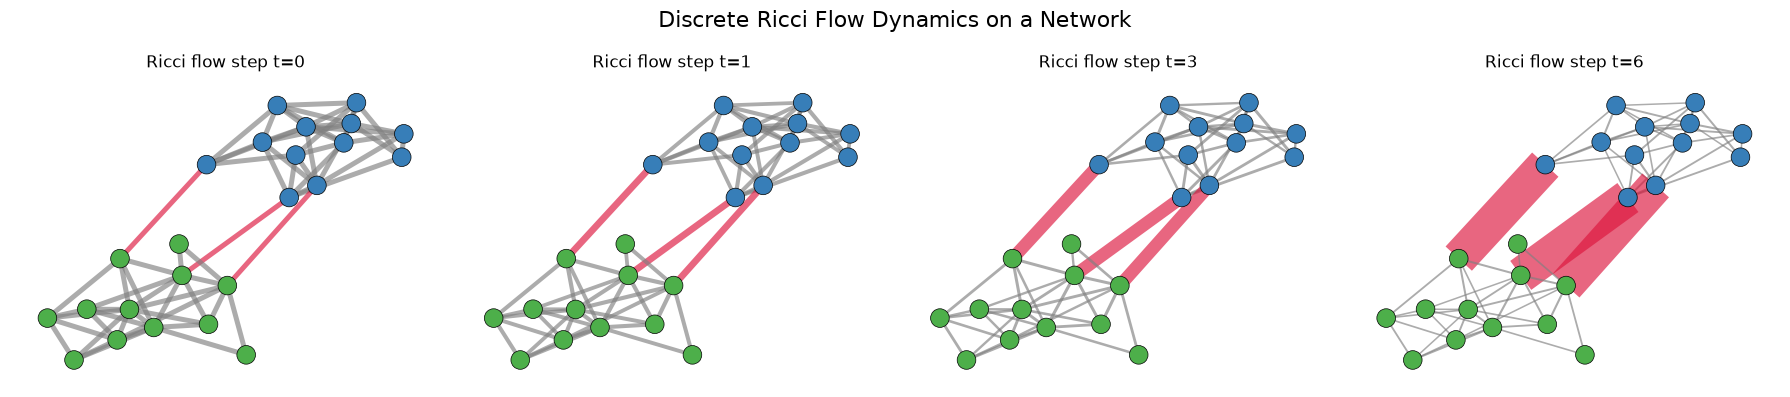

In [18]:

np.random.seed(42)

# toy graph: two communities connected by bridges
G = nx.Graph()
left = range(0, 12)
right = range(12, 24)

G.add_nodes_from(left)
G.add_nodes_from(right)

for group in [left, right]:
    for i in group:
        for j in group:
            if i < j and np.random.rand() < 0.45:
                G.add_edge(i, j, weight=1.0)

bridges = [(3, 15), (5, 18), (8, 20)]
G.add_edges_from(bridges, weight=1.0)

pos = nx.spring_layout(G, seed=4)

# fake curvature values for illustration
for u, v in G.edges():
    if (u, v) in bridges or (v, u) in bridges:
        G[u][v]["curvature"] = -0.55
    else:
        G[u][v]["curvature"] = 0.25 + 0.15 * np.random.rand()

eta = 0.8
steps = [0, 1, 3, 6]

graphs = []

for t in range(max(steps) + 1):
    H = G.copy()
    for u, v in H.edges():
        kappa = H[u][v]["curvature"]
        H[u][v]["weight"] = G[u][v]["weight"] * ((1 - eta * kappa) ** t)
    graphs.append(H)

fig, axes = plt.subplots(1, len(steps), figsize=(18, 4))

for ax, t in zip(axes, steps):
    H = graphs[t]
    widths = [0.8 + 2.8 * H[u][v]["weight"] for u, v in H.edges()]
    
    edge_colors = [
        "crimson" if H[u][v]["curvature"] < 0 else "gray"
        for u, v in H.edges()
    ]

    node_colors = ["#377eb8" if n in left else "#4daf4a" for n in H.nodes()]

    nx.draw_networkx_edges(
        H, pos, ax=ax,
        width=widths,
        edge_color=edge_colors,
        alpha=0.65
    )
    nx.draw_networkx_nodes(
        H, pos, ax=ax,
        node_color=node_colors,
        node_size=180,
        edgecolors="black",
        linewidths=0.5
    )

    ax.set_title(f"Ricci flow step t={t}")
    ax.axis("off")

plt.suptitle("Discrete Ricci Flow Dynamics on a Network", fontsize=16)
plt.tight_layout()
plt.show()

fig.savefig(FIGURES_DIR / "fig4_discrete_ricci_flow_dynamics.png", dpi=400, bbox_inches="tight")
fig.savefig(FIGURES_DIR / "fig4_discrete_ricci_flow_dynamics.pdf", bbox_inches="tight")

In [19]:
configs_for_paper = [
    (0,  10, 0.50),
    (10, 30, 0.25),
    (20, 25, 0.75),
    (25, 30, 0.75),
    (30, 20, 0.50),
]

paper_rows = []

for lrc_pct, orc_pct, alpha in configs_for_paper:

    rows = evaluate_combo_configuration(
        lrc_pct=lrc_pct,
        orc_pct=orc_pct,
        alpha=alpha,
        seeds=SENSITIVITY_SEEDS,
    )

    df_temp = pd.DataFrame(rows)

    paper_rows.append({
        "p_LRC": lrc_pct,
        "p_ORC": orc_pct,
        "alpha": alpha,
        "ARI": df_temp["ARI"].mean(),
        "NMI": df_temp["NMI"].mean(),
        "Runtime": df_temp["Runtime"].mean(),
    })

paper_table = pd.DataFrame(paper_rows)

display(paper_table.round(3))

,p_LRC,p_ORC,alpha,ARI,NMI,Runtime
0,0,10,0.50,0.838,0.816,20.305
1,10,30,0.25,0.788,0.765,11.806
2,20,25,0.75,0.751,0.735,12.335
3,25,30,0.75,0.710,0.709,10.765
4,30,20,0.50,0.718,0.707,8.558
